# Person Identification & Clustering — Computer Vision Assessment


## 1. Setup




In [1]:
!pip install facenet-pytorch

In [2]:
!pip install -q facenet-pytorch opencv-python-headless tqdm scikit-learn matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 11.8 MB/s eta 0:00:00


In [3]:
import os
import glob
import shutil
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Using device: cpu


In [4]:
from google.colab import files

uploaded = files.upload()

Saving person_identification-20260705T135624Z-3-001.zip to person_identification-20260705T135624Z-3-001.zip


In [5]:
import zipfile

In [6]:
zip_path = "/content/person_identification-20260705T135624Z-3-001.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


## 2. Configuration



In [7]:
DATASET_DIR = "/content/dataset/person_identification"
OUTPUT_DIR = "output"
EMBEDDINGS_CACHE = "embeddings.npy"

# Clustering sensitivity: lower eps = stricter (more, smaller clusters),
# higher eps = looser (fewer, bigger clusters). 0.35-0.45 works well for
# cosine distance on FaceNet-512 embeddings; tune on a validation subset if available.
DBSCAN_EPS = 0.40
DBSCAN_MIN_SAMPLES = 1   # allow clusters/singletons of size 1 (rare/unique faces still get a group)

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

os.makedirs(OUTPUT_DIR, exist_ok=True)

image_paths = sorted([
    p for p in glob.glob(os.path.join(DATASET_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMAGE_EXTS)
])
print(f"Found {len(image_paths)} images in {DATASET_DIR}")
image_paths[:10]


Found 6 images in /content/dataset/person_identification


['/content/dataset/person_identification/person_01_0.jpg',
 '/content/dataset/person_identification/person_01_1.jpg',
 '/content/dataset/person_identification/person_02_0.jpg',
 '/content/dataset/person_identification/person_02_1.jpg',
 '/content/dataset/person_identification/person_03_0.jpg',
 '/content/dataset/person_identification/person_03_1.jpg']

## 3. Face detection + embedding extraction


In [8]:
mtcnn = MTCNN(
    image_size=160, margin=20, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], post_process=True,
    keep_all=True, device=device
)
resnet = InceptionResnetV1(pretrained="vggface2").eval().to(device)


def get_largest_face(boxes, probs):
    """Return the index of the largest-area detected face box."""
    areas = [(b[2] - b[0]) * (b[3] - b[1]) for b in boxes]
    return int(np.argmax(areas))


def extract_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    boxes, probs = mtcnn.detect(img)
    if boxes is None or len(boxes) == 0:
        return None, None

    idx = get_largest_face(boxes, probs) if len(boxes) > 1 else 0
    face_tensors = mtcnn.extract(img, boxes[idx:idx+1], save_path=None)
    if face_tensors is None:
        return None, None

    face_tensor = face_tensors[0].unsqueeze(0).to(device)
    with torch.no_grad():
        emb = resnet(face_tensor).cpu().numpy().flatten()
    return emb, float(probs[idx])


records = []       # per-image metadata
embeddings = []     # matching embedding rows
skipped = []        # images with no detectable face

for path in tqdm(image_paths, desc="Extracting embeddings"):
    emb, det_conf = extract_embedding(path)
    if emb is None:
        skipped.append(path)
        continue
    records.append({"path": path, "filename": os.path.basename(path), "det_confidence": det_conf})
    embeddings.append(emb)

embeddings = np.vstack(embeddings) if embeddings else np.empty((0, 512))
print(f"Embeddings extracted: {len(embeddings)}")
print(f"Images skipped (no face detected): {len(skipped)}")
if skipped:
    print("Skipped files:", skipped)


  0%|          | 0.00/107M [00:00<?, ?B/s]

Extracting embeddings:   0%|          | 0/6 [00:00<?, ?it/s]

Embeddings extracted: 6
Images skipped (no face detected): 0


In [9]:
# Cache embeddings so re-running the clustering cells doesn't require re-running the model
np.save(EMBEDDINGS_CACHE, embeddings)
df = pd.DataFrame(records)
df.head()


,path,filename,det_confidence
0,/content/dataset/person_identification/person_...,person_01_0.jpg,0.895650
1,/content/dataset/person_identification/person_...,person_01_1.jpg,0.998596
2,/content/dataset/person_identification/person_...,person_02_0.jpg,0.999924
3,/content/dataset/person_identification/person_...,person_02_1.jpg,0.999628
4,/content/dataset/person_identification/person_...,person_03_0.jpg,0.995414


## 4. Clustering



In [10]:
norm_embeddings = normalize(embeddings, norm="l2")

# cosine distance = 1 - cosine similarity
clusterer = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, metric="cosine")
labels = clusterer.fit_predict(norm_embeddings)

df["cluster_raw"] = labels

# DBSCAN's noise label is -1; give every noise point its own singleton cluster
# instead of lumping all unmatched faces together.
next_id = df["cluster_raw"].max() + 1 if (df["cluster_raw"] >= 0).any() else 0
new_labels = df["cluster_raw"].copy()
for i in df.index[df["cluster_raw"] == -1]:
    new_labels.loc[i] = next_id
    next_id += 1
df["cluster_id"] = new_labels

n_clusters = df["cluster_id"].nunique()
print(f"Discovered {n_clusters} identity clusters across {len(df)} images")
df.groupby("cluster_id").size().sort_values(ascending=False)


Discovered 3 identity clusters across 6 images


,0
cluster_id,
0,2
1,2
2,2


## 5. Per-image confidence score



In [11]:
def rescale(sim):
    """cosine similarity [-1,1] -> confidence [0,100]"""
    return float(np.clip((sim + 1) / 2 * 100, 0, 100))

full_sim_matrix = cosine_similarity(norm_embeddings)
confidences = []

for i, row in df.iterrows():
    cid = row["cluster_id"]
    members = df.index[df["cluster_id"] == cid].tolist()
    others = [m for m in members if m != i]

    if others:
        centroid = norm_embeddings[others].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
        sim = float(np.dot(norm_embeddings[i], centroid))
    else:
        # singleton: fall back to similarity with the single closest face overall
        sims = full_sim_matrix[i].copy()
        sims[i] = -1
        sim = float(np.max(sims))

    confidences.append(round(rescale(sim), 2))

df["confidence"] = confidences
df.sort_values(["cluster_id", "confidence"], ascending=[True, False])


,path,filename,det_confidence,cluster_raw,cluster_id,confidence
0,/content/dataset/person_identification/person_...,person_01_0.jpg,0.895650,0,0,84.80
1,/content/dataset/person_identification/person_...,person_01_1.jpg,0.998596,0,0,84.80
2,/content/dataset/person_identification/person_...,person_02_0.jpg,0.999924,1,1,81.88
3,/content/dataset/person_identification/person_...,person_02_1.jpg,0.999628,1,1,81.88
4,/content/dataset/person_identification/person_...,person_03_0.jpg,0.995414,2,2,89.77
5,/content/dataset/person_identification/person_...,person_03_1.jpg,0.995247,2,2,89.77


In [12]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

results = {"clusters": {}, "skipped_no_face_detected": skipped}

for cid, group in df.groupby("cluster_id"):
    cluster_dir = os.path.join(OUTPUT_DIR, f"cluster_{int(cid):02d}")
    os.makedirs(cluster_dir, exist_ok=True)
    members = []
    for _, row in group.iterrows():
        conf_tag = f"{row['confidence']:.1f}".replace(".", "_")
        dest_name = f"{conf_tag}pct__{row['filename']}"
        shutil.copy(row["path"], os.path.join(cluster_dir, dest_name))
        members.append({
            "filename": row["filename"],
            "original_path": row["path"],
            "confidence": row["confidence"],
            "detection_confidence": round(row["det_confidence"], 3),
        })
    results["clusters"][f"cluster_{int(cid):02d}"] = members

with open(os.path.join(OUTPUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

df.to_csv(os.path.join(OUTPUT_DIR, "manifest.csv"), index=False)
print(f"Saved organized clusters + results.json + manifest.csv to '{OUTPUT_DIR}/'")


Saved organized clusters + results.json + manifest.csv to 'output/'


## 7. Visualize the clusters



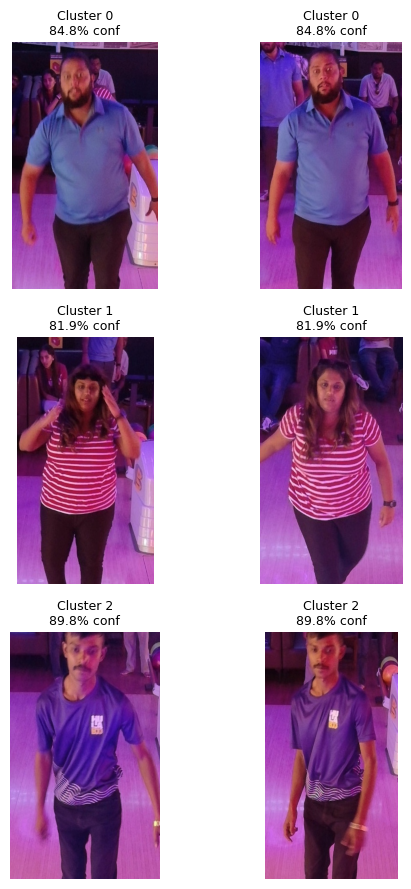

In [13]:
cluster_ids = sorted(df["cluster_id"].unique())
max_per_row = max(df.groupby("cluster_id").size().max(), 1)

fig, axes = plt.subplots(len(cluster_ids), max_per_row,
                          figsize=(3 * max_per_row, 3 * len(cluster_ids)))
if len(cluster_ids) == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

for r, cid in enumerate(cluster_ids):
    group = df[df["cluster_id"] == cid].reset_index(drop=True)
    for c in range(max_per_row):
        ax = axes[r][c]
        ax.axis("off")
        if c < len(group):
            row = group.iloc[c]
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"Cluster {int(cid)}\n{row['confidence']:.1f}% conf", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_grid.png"), dpi=150)
plt.show()


## 8. Summary report


In [14]:
print("="*50)
print("PERSON IDENTIFICATION - SUMMARY")
print("="*50)
print(f"Total images processed : {len(image_paths)}")
print(f"Faces embedded         : {len(df)}")
print(f"Images skipped (no face): {len(skipped)}")
print(f"Identity clusters found: {df['cluster_id'].nunique()}")
print(f"Average confidence     : {df['confidence'].mean():.2f}%")
print()
print(df.groupby('cluster_id')['confidence'].agg(['count', 'mean', 'min', 'max']))


PERSON IDENTIFICATION - SUMMARY
Total images processed : 6
Faces embedded         : 6
Images skipped (no face): 0
Identity clusters found: 3
Average confidence     : 85.48%

            count   mean    min    max
cluster_id                            
0               2  84.80  84.80  84.80
1               2  81.88  81.88  81.88
2               2  89.77  89.77  89.77


## 9. Sanity-check against filenames


In [15]:
import re
from sklearn.metrics import adjusted_rand_score

def extract_true_id(filename):
    m = re.match(r"person_(\d+)_", filename)
    return m.group(1) if m else None

df["true_id"] = df["filename"].apply(extract_true_id)

if df["true_id"].notna().all():
    ari = adjusted_rand_score(df["true_id"], df["cluster_id"])
    print(f"Adjusted Rand Index vs filename-derived ground truth: {ari:.3f}  (1.0 = perfect)")
else:
    print("Filenames don't follow the 'person_<id>_<idx>' convention — skipping this check.")


Adjusted Rand Index vs filename-derived ground truth: 1.000  (1.0 = perfect)


In [18]:
import shutil

# Create output.zip from the output folder
shutil.make_archive('/content/output', 'zip', '/content/output')

print("✅ output.zip created successfully!")

✅ output.zip created successfully!
